# Week 3: Multi-View Reconstruction


This notebook implements a sequential, multi-view Structure from Motion (SfM) pipeline. It sequentially reconstructs 3D points and camera poses from a sequence of images (photo1.jpeg to photo33.jpeg).


Setup and Configuration

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import open3d as o3d
import os
import sys

# Append parent directory to path to import local modules
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

# Import local utility functions
from src.feature_matching import find_and_filter_matches
from src.reconstruction import (
    get_intrinsic_matrix,
    get_points_from_matches,
    reconstruct_two_views,
    create_point_cloud
)


In [2]:
data_dir = os.path.join(module_path, 'ds')

# Generate full sequence: photo1.jpeg to photo33.jpeg
IMAGE_SEQUENCE = [f'photo{i}.jpeg' for i in range(1, 34)]

print("="*70)
print(f"IMPROVED SfM (FAST VERSION): {len(IMAGE_SEQUENCE)} IMAGES")
print("="*70)
print(f"Sequence: photo1.jpeg → photo2.jpeg → ... → photo33.jpeg\n")

# Optimized parameters for better reconstruction
MIN_MATCHES = 15               # Minimum matches to attempt reconstruction
MIN_POINTS = 10                # Minimum 3D points to accept reconstruction
LOWE_RATIO = 0.75              # Feature matching ratio (0.6-0.8)
SCALE_SMOOTHING = 0.8          # How much to trust scale estimation (0-1)
OUTLIER_STD_THRESHOLD = 2.0    # Standard deviations for outlier removal
DUPLICATE_THRESHOLD = 0.1      # Distance threshold for duplicate points

print("Parameters:")
print(f"  Min matches required: {MIN_MATCHES}")
print(f"  Min 3D points required: {MIN_POINTS}")
print(f"  Lowe ratio threshold: {LOWE_RATIO}")
print(f"  Scale smoothing factor: {SCALE_SMOOTHING}")
print(f"  Duplicate threshold: {DUPLICATE_THRESHOLD}")
print()

IMPROVED SfM (FAST VERSION): 33 IMAGES
Sequence: photo1.jpeg → photo2.jpeg → ... → photo33.jpeg

Parameters:
  Min matches required: 15
  Min 3D points required: 10
  Lowe ratio threshold: 0.75
  Scale smoothing factor: 0.8
  Duplicate threshold: 0.1



Global Reconstruction Class

In [3]:
# ============================================================================
# ROBUST GLOBAL RECONSTRUCTION CLASS
# ============================================================================

class RobustGlobalReconstruction:
    def __init__(self):
        self.points_3d = []
        self.point_colors = []
        self.camera_poses = []
        self.point_sources = []
        self.pair_stats = []
        
    def add_initial_pair(self, points_3d, colors, R, t, pair_idx):
        """Initialize with first successful pair"""
        self.camera_poses.append((np.eye(3), np.zeros((3, 1))))
        self.camera_poses.append((R, t))
        
        self.points_3d = points_3d.tolist()
        self.point_colors = colors.tolist()
        self.point_sources = [pair_idx] * len(points_3d)
        
        self.pair_stats.append({
            'pair_idx': pair_idx,
            'status': 'initialized',
            'num_points': len(points_3d)
        })
        
    def add_next_view(self, points_3d_new, colors_new, R_rel, t_rel, pair_idx):
        """Add new view with robust scale normalization"""
        R_prev, t_prev = self.camera_poses[-1]
        
        # Scale normalization with smoothing
        if len(self.camera_poses) > 1:
            R_prev_prev, t_prev_prev = self.camera_poses[-2]
            prev_motion = np.linalg.norm(t_prev - t_prev_prev)
            
            current_motion = np.linalg.norm(t_rel)
            if current_motion > 1e-6 and prev_motion > 1e-6:
                scale_factor = prev_motion / current_motion
                # Smooth scale changes
                scale_factor = SCALE_SMOOTHING * scale_factor + (1 - SCALE_SMOOTHING) * 1.0
                # Clamp to reasonable range
                scale_factor = np.clip(scale_factor, 0.3, 3.0)
                
                t_rel = t_rel * scale_factor
                points_3d_new = points_3d_new * scale_factor
        
        # Compute new camera pose
        R_new = R_prev @ R_rel
        t_new = R_prev @ t_rel + t_prev
        
        self.camera_poses.append((R_new, t_new))
        
        # Transform and add points
        points_added = 0
        for i, pt in enumerate(points_3d_new):
            pt_world = R_prev @ pt.reshape(3, 1) + t_prev
            
            # Duplicate check with smaller threshold
            is_duplicate = False
            if len(self.points_3d) > 0:
                recent_points = np.array(self.points_3d[-2000:])
                distances = np.linalg.norm(recent_points - pt_world.flatten(), axis=1)
                if np.min(distances) < DUPLICATE_THRESHOLD:
                    is_duplicate = True
            
            if not is_duplicate:
                self.points_3d.append(pt_world.flatten())
                self.point_colors.append(colors_new[i])
                self.point_sources.append(pair_idx)
                points_added += 1
        
        self.pair_stats.append({
            'pair_idx': pair_idx,
            'status': 'added',
            'num_points': points_added
        })
        
        return points_added
    
    def skip_pair(self, pair_idx, reason):
        """Record a skipped pair"""
        if len(self.camera_poses) > 0:
            self.camera_poses.append(self.camera_poses[-1])
        
        self.pair_stats.append({
            'pair_idx': pair_idx,
            'status': 'skipped',
            'reason': reason,
            'num_points': 0
        })

Sequential Reconstruction Pipeline

In [4]:

# Get intrinsic matrix from first image
first_img = cv2.imread(os.path.join(data_dir, IMAGE_SEQUENCE[0]))
if first_img is None:
    print(f"❌ ERROR: Could not load {IMAGE_SEQUENCE[0]}")
    sys.exit(1)

K = get_intrinsic_matrix(first_img.shape)
print("Intrinsic Matrix K:")
print(K)
print()

global_recon = RobustGlobalReconstruction()

print("="*70)
print("SEQUENTIAL RECONSTRUCTION")
print("="*70)

initialization_done = False

# Process each consecutive pair
for i in range(len(IMAGE_SEQUENCE) - 1):
    pair_name = f"{IMAGE_SEQUENCE[i]} → {IMAGE_SEQUENCE[i+1]}"
    
    print(f"\n{'='*70}")
    print(f"Pair {i+1}/{len(IMAGE_SEQUENCE)-1}: {pair_name}")
    print(f"{'='*70}")
    
    # Load images
    img1 = cv2.imread(os.path.join(data_dir, IMAGE_SEQUENCE[i]))
    img2 = cv2.imread(os.path.join(data_dir, IMAGE_SEQUENCE[i+1]))
    
    if img1 is None or img2 is None:
        print(f"❌ Could not load images")
        global_recon.skip_pair(i, "images_not_found")
        continue
    
    # Find matches
    try:
        matches, kp1, kp2, _ = find_and_filter_matches(img1, img2, lowe_ratio=LOWE_RATIO)
    except Exception as e:
        print(f"❌ Feature matching failed: {e}")
        global_recon.skip_pair(i, "matching_failed")
        continue
    
    if len(matches) < MIN_MATCHES:
        print(f"❌ Only {len(matches)} matches (need {MIN_MATCHES}+) - insufficient overlap")
        global_recon.skip_pair(i, f"too_few_matches_{len(matches)}")
        continue
    
    pts1, pts2 = get_points_from_matches(matches, kp1, kp2)
    print(f"✓ Found {len(matches)} matches")
    
    # Two-view reconstruction
    try:
        points_3d_rel, R_rel, t_rel, pts1_inliers = reconstruct_two_views(pts1, pts2, K)
        print(f"✓ Reconstructed {len(points_3d_rel)} 3D points")
    except Exception as e:
        print(f"❌ Reconstruction failed: {e}")
        global_recon.skip_pair(i, "reconstruction_failed")
        continue
    
    if len(points_3d_rel) < MIN_POINTS:
        print(f"❌ Only {len(points_3d_rel)} 3D points (need {MIN_POINTS}+)")
        global_recon.skip_pair(i, f"too_few_points_{len(points_3d_rel)}")
        continue
    
    # Get colors (using inlier points)
    img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
    colors = []
    for pt in pts1_inliers:
        x, y = int(pt[0]), int(pt[1])
        if 0 <= y < img1_rgb.shape[0] and 0 <= x < img1_rgb.shape[1]:
            colors.append(img1_rgb[y, x] / 255.0)
        else:
            colors.append([0.5, 0.5, 0.5])
    colors = np.array(colors)
    
    # Add to reconstruction
    if not initialization_done:
        global_recon.add_initial_pair(points_3d_rel, colors, R_rel, t_rel, i)
        initialization_done = True
        print(f"✓ ✨ INITIALIZED reconstruction with {len(points_3d_rel)} points")
        print(f"  Base cameras: {IMAGE_SEQUENCE[i]} (origin) and {IMAGE_SEQUENCE[i+1]}")
    else:
        points_added = global_recon.add_next_view(points_3d_rel, colors, R_rel, t_rel, i)
        print(f"✓ Added {points_added} new points (after duplicate filtering)")
        print(f"  Total points: {len(global_recon.points_3d)}")
        print(f"  Total cameras: {len(global_recon.camera_poses)}")

Intrinsic Matrix K:
[[3.024e+03 0.000e+00 1.512e+03]
 [0.000e+00 3.024e+03 2.016e+03]
 [0.000e+00 0.000e+00 1.000e+00]]

SEQUENTIAL RECONSTRUCTION

Pair 1/32: photo1.jpeg → photo2.jpeg
Found 7062 keypoints in img1 and 2942 in img2.
Found 7062 initial matches.
Filtered down to 362 good matches using Lowe's ratio test.
✓ Found 362 matches
Essential Matrix found. Inliers: 249 / 362
✓ Reconstructed 249 3D points
✓ ✨ INITIALIZED reconstruction with 249 points
  Base cameras: photo1.jpeg (origin) and photo2.jpeg

Pair 2/32: photo2.jpeg → photo3.jpeg
Found 2942 keypoints in img1 and 1396 in img2.
Found 2942 initial matches.
Filtered down to 313 good matches using Lowe's ratio test.
✓ Found 313 matches
Essential Matrix found. Inliers: 234 / 313
✓ Reconstructed 234 3D points
✓ Added 124 new points (after duplicate filtering)
  Total points: 373
  Total cameras: 3

Pair 3/32: photo3.jpeg → photo4.jpeg
Found 1396 keypoints in img1 and 4142 in img2.
Found 1396 initial matches.
Filtered down to 334

Results and Visualization


RECONSTRUCTION COMPLETE
Images processed: 33
Camera poses: 33
Total 3D points: 4888

Pair statistics:
  Successful: 31/32
  Skipped: 1/32

⚠️ Skipped pairs:
    Pair 12: photo12.jpeg → photo13.jpeg
      Reason: too_few_points_9

Filtering outliers...
Filtered 27 outliers (0.6%)
Final point cloud: 4861 points



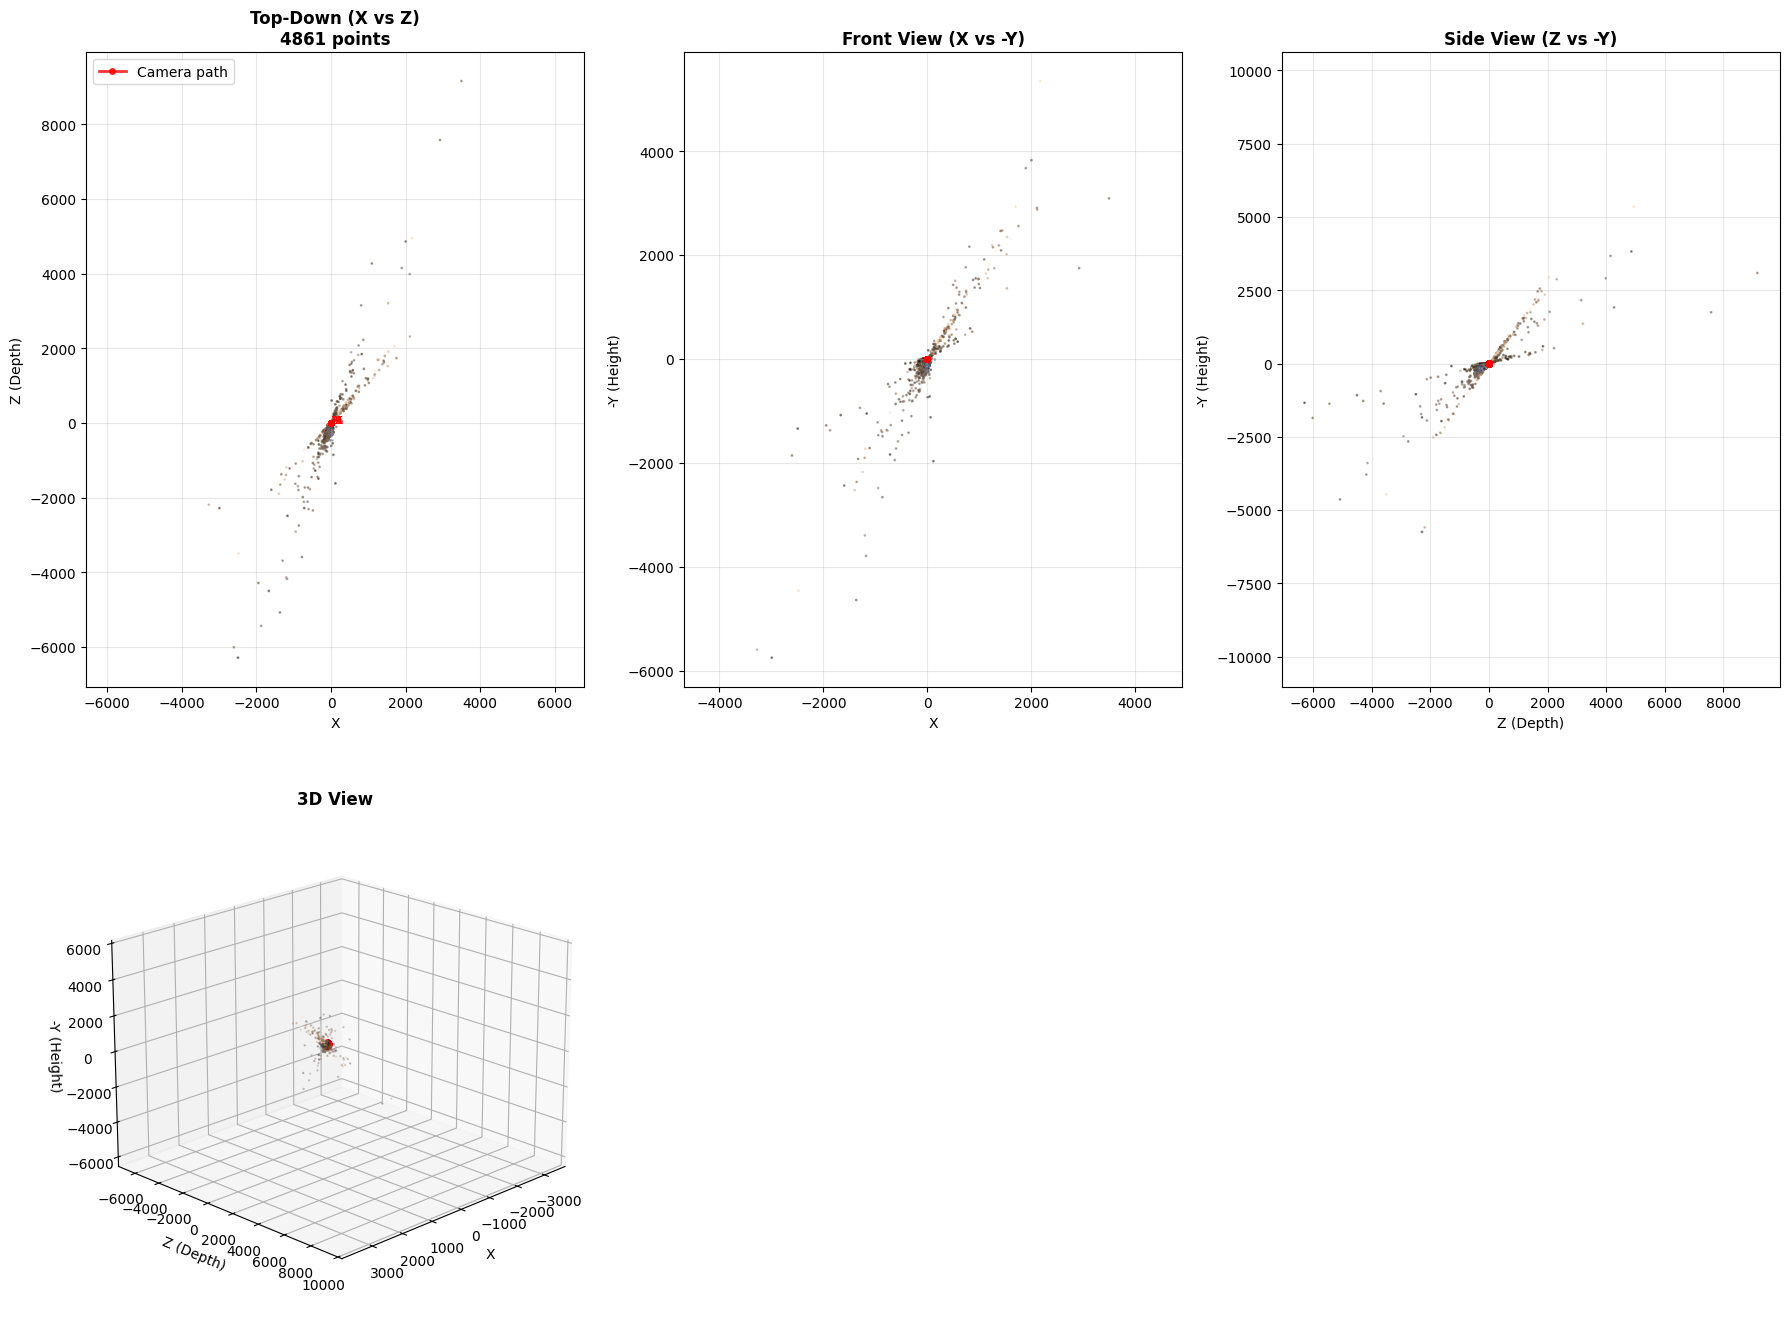

Creating 3D visualization...
✓ Saved week3_improved_fast_reconstruction.ply

Opening 3D viewer...
Colored points: Reconstructed scene
Red points: Camera positions
Red lines: Camera trajectory

FINAL RECONSTRUCTION SUMMARY
Dataset: photo1.jpeg to photo33.jpeg (33 images)
Cameras registered: 33
Total points: 4861
Points per camera: 147.3

Point cloud extent:
  X: [-3275.80, 3493.92] (range: 6769.73)
  Y: [-5347.46, 5745.86] (range: 11093.32)
  Z: [-6291.39, 9159.49] (range: 15450.87)

Camera trajectory:
  Total length: 37.70 units
  Average step: 1.18 units


In [5]:
# ============================================================================
# RECONSTRUCTION STATISTICS
# ============================================================================

print(f"\n{'='*70}")
print(f"RECONSTRUCTION COMPLETE")
print(f"{'='*70}")
print(f"Images processed: {len(IMAGE_SEQUENCE)}")
print(f"Camera poses: {len(global_recon.camera_poses)}")
print(f"Total 3D points: {len(global_recon.points_3d)}")

successful_pairs = sum(1 for stat in global_recon.pair_stats if stat['status'] != 'skipped')
skipped_pairs = sum(1 for stat in global_recon.pair_stats if stat['status'] == 'skipped')

print(f"\nPair statistics:")
print(f"  Successful: {successful_pairs}/{len(IMAGE_SEQUENCE)-1}")
print(f"  Skipped: {skipped_pairs}/{len(IMAGE_SEQUENCE)-1}")

if skipped_pairs > 0:
    print(f"\n⚠️ Skipped pairs:")
    for stat in global_recon.pair_stats:
        if stat['status'] == 'skipped':
            pair_idx = stat['pair_idx']
            print(f"    Pair {pair_idx+1}: {IMAGE_SEQUENCE[pair_idx]} → {IMAGE_SEQUENCE[pair_idx+1]}")
            print(f"      Reason: {stat['reason']}")

print(f"{'='*70}\n")

# ============================================================================
# VISUALIZATION
# ============================================================================

if len(global_recon.points_3d) == 0:
    print(" No 3D points reconstructed!")
    
else:
    all_points = np.array(global_recon.points_3d)
    all_colors = np.array(global_recon.point_colors)
    
    print("Filtering outliers...")
    
    # Outlier removal
    mean = np.mean(all_points, axis=0)
    std = np.std(all_points, axis=0)
    
    mask = (np.abs(all_points - mean) < OUTLIER_STD_THRESHOLD * std).all(axis=1)
    clean_points = all_points[mask]
    clean_colors = all_colors[mask]
    
    outliers_removed = len(all_points) - len(clean_points)
    print(f"Filtered {outliers_removed} outliers ({outliers_removed/len(all_points)*100:.1f}%)")
    print(f"Final point cloud: {len(clean_points)} points\n")
    
    # Get camera centers
    camera_centers = []
    for R, t in global_recon.camera_poses:
        C = -R.T @ t
        camera_centers.append(C.flatten())
    camera_centers = np.array(camera_centers)
    
    # ========================================================================
    # 2D PROJECTIONS
    # ========================================================================
    
    fig = plt.figure(figsize=(18, 14))
    
    # Top-Down View
    ax1 = plt.subplot(2, 3, 1)
    ax1.scatter(clean_points[:, 0], clean_points[:, 2], s=1, c=clean_colors, alpha=0.5)
    ax1.plot(camera_centers[:, 0], camera_centers[:, 2], 'r-o', 
             linewidth=2, markersize=4, label='Camera path', alpha=0.8)
    for idx in range(0, len(camera_centers), 5):
        ax1.text(camera_centers[idx, 0], camera_centers[idx, 2], 
                str(idx+1), color='red', fontsize=7)
    ax1.set_title(f"Top-Down (X vs Z)\n{len(clean_points)} points", fontweight='bold')
    ax1.set_xlabel("X")
    ax1.set_ylabel("Z (Depth)")
    ax1.axis('equal')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # Front View
    ax2 = plt.subplot(2, 3, 2)
    ax2.scatter(clean_points[:, 0], -clean_points[:, 1], s=1, c=clean_colors, alpha=0.5)
    ax2.plot(camera_centers[:, 0], -camera_centers[:, 1], 'r-o', 
             linewidth=2, markersize=4, alpha=0.8)
    ax2.set_title("Front View (X vs -Y)", fontweight='bold')
    ax2.set_xlabel("X")
    ax2.set_ylabel("-Y (Height)")
    ax2.axis('equal')
    ax2.grid(True, alpha=0.3)
    
    # Side View
    ax3 = plt.subplot(2, 3, 3)
    ax3.scatter(clean_points[:, 2], -clean_points[:, 1], s=1, c=clean_colors, alpha=0.5)
    ax3.plot(camera_centers[:, 2], -camera_centers[:, 1], 'r-o', 
             linewidth=2, markersize=4, alpha=0.8)
    ax3.set_title("Side View (Z vs -Y)", fontweight='bold')
    ax3.set_xlabel("Z (Depth)")
    ax3.set_ylabel("-Y (Height)")
    ax3.axis('equal')
    ax3.grid(True, alpha=0.3)
    
    # 3D View
    from mpl_toolkits.mplot3d import Axes3D
    ax4 = plt.subplot(2, 3, 4, projection='3d')
    ax4.scatter(clean_points[:, 0], clean_points[:, 2], -clean_points[:, 1], 
                s=0.5, c=clean_colors, alpha=0.3)
    ax4.plot(camera_centers[:, 0], camera_centers[:, 2], -camera_centers[:, 1], 
             'r-o', linewidth=3, markersize=6)
    ax4.set_xlabel('X')
    ax4.set_ylabel('Z (Depth)')
    ax4.set_zlabel('-Y (Height)')
    ax4.set_title('3D View', fontweight='bold')
    ax4.view_init(elev=20, azim=45)
    
    plt.tight_layout()
    plt.show()
    
    # ========================================================================
    # OPEN3D VISUALIZATION
    # ========================================================================
    
    print("Creating 3D visualization...")
    pcd = create_point_cloud(clean_points, clean_colors)
    
    # Camera visualization
    camera_pcd = o3d.geometry.PointCloud()
    camera_pcd.points = o3d.utility.Vector3dVector(camera_centers)
    camera_pcd.paint_uniform_color([1, 0, 0])
    
    # Camera trajectory
    lines = [[i, i+1] for i in range(len(camera_centers)-1)]
    line_set = o3d.geometry.LineSet()
    line_set.points = o3d.utility.Vector3dVector(camera_centers)
    line_set.lines = o3d.utility.Vector2iVector(lines)
    line_set.colors = o3d.utility.Vector3dVector([[1, 0, 0] for _ in lines])
    
    # Save
    output_file = "week3_improved_fast_reconstruction.ply"
    o3d.io.write_point_cloud(output_file, pcd)
    print(f"✓ Saved {output_file}\n")
    
    # Visualize
    print("Opening 3D viewer...")
    print("Colored points: Reconstructed scene")
    print("Red points: Camera positions")
    print("Red lines: Camera trajectory\n")
    

    o3d.visualization.draw_geometries(
        [pcd, line_set, camera_pcd],
        window_name=f"Improved SfM (Fast): {len(clean_points)} points, {len(camera_centers)} cameras",
        width=1400,
        height=900
    )
    
    # ========================================================================
    # FINAL SUMMARY
    # ========================================================================
    

    print("FINAL RECONSTRUCTION SUMMARY")
    print("="*70)
    print(f"Dataset: photo1.jpeg to photo33.jpeg ({len(IMAGE_SEQUENCE)} images)")
    print(f"Cameras registered: {len(global_recon.camera_poses)}")
    print(f"Total points: {len(clean_points)}")
    print(f"Points per camera: {len(clean_points)/len(global_recon.camera_poses):.1f}")
    print(f"\nPoint cloud extent:")
    print(f"  X: [{clean_points[:, 0].min():.2f}, {clean_points[:, 0].max():.2f}] (range: {clean_points[:, 0].max()-clean_points[:, 0].min():.2f})")
    print(f"  Y: [{clean_points[:, 1].min():.2f}, {clean_points[:, 1].max():.2f}] (range: {clean_points[:, 1].max()-clean_points[:, 1].min():.2f})")
    print(f"  Z: [{clean_points[:, 2].min():.2f}, {clean_points[:, 2].max():.2f}] (range: {clean_points[:, 2].max()-clean_points[:, 2].min():.2f})")
    
    trajectory_length = np.sum([
        np.linalg.norm(camera_centers[i+1] - camera_centers[i]) 
        for i in range(len(camera_centers)-1)
    ])
    print(f"\nCamera trajectory:")
    print(f"  Total length: {trajectory_length:.2f} units")
    print(f"  Average step: {trajectory_length/(len(camera_centers)-1):.2f} units")

In [ ]:
import json
import numpy as np
import open3d as o3d

print("--- STARTING EXPORT ---")

points = np.asarray(clean_points)
colors = np.asarray(clean_colors)

# 2. Fix Color Range 
if colors.max() > 1.0:
    print("Normalizing colors from 0-255 to 0-1 range.")
    colors = colors / 255.0

# 3. Center the Cloud at (0,0,0)
centroid = np.mean(points, axis=0)
points_centered = points - centroid
print(f"Centering cloud. Subtracting {centroid}")

# 4. Create Open3D Object
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points_centered)
pcd.colors = o3d.utility.Vector3dVector(colors)

# 5. Export PLY
print(f"Saving 'point_cloud.ply' with {len(points)} points...")
o3d.io.write_point_cloud("point_cloud.ply", pcd)

# 6. Export Cameras
print("Exporting cameras...")
camera_export = []

# OpenCV -> OpenGL Transform
cv_to_gl = np.array([
    [1,  0,  0,  0],
    [0, -1,  0,  0],
    [0,  0, -1,  0],
    [0,  0,  0,  1]
])

# Handle list structure of global_recon.camera_poses
poses = global_recon.camera_poses
iterator = enumerate(poses) if isinstance(poses, list) else poses.items()

for idx, pose_data in iterator:
    if pose_data is None: continue
    
    R, t = pose_data
    
    # World-to-Camera matrix
    extrinsic = np.eye(4)
    extrinsic[:3, :3] = R
    extrinsic[:3, 3] = t.flatten() if hasattr(t, 'flatten') else t
    
    try:
        # Invert to get Camera-to-World (Position)
        cam_pose = np.linalg.inv(extrinsic)
        
        # Apply same centering offset to camera
        cam_pose[:3, 3] -= centroid
        
        # Convert coordinate system
        cam_pose = cam_pose @ cv_to_gl
        
        camera_export.append({
            "id": idx,
            "pose_matrix": cam_pose.flatten().tolist()
        })
        
    except Exception as e:
        print(f"Skipped frame {idx}: {e}")

with open("cameras.json", "w") as f:
    json.dump(camera_export, f)

print(f"Done! Saved {len(camera_export)} cameras to 'cameras.json'")

--- STARTING EXPORT ---
Centering cloud. Subtracting [  2.32257702  26.96567684 -46.6571237 ]
Saving 'point_cloud.ply' with 4861 points...
Exporting cameras...
Done! Saved 33 cameras to 'cameras.json'
